
## 🚀 **Introduction & Setup**


🏞️ Gold Mine Exploration in Western Australia

This project analyzes open-file mineral exploration drillhole data from the Western Australian Department of Mines, Industry Regulation and Safety (DMIRS). The goal is to examine historical gold exploration activity by evaluating drillhole locations, geological logs, assay results, and more, with an emphasis on uncovering patterns that may inform future gold mining prospects.

The data primarily includes:
- Collar data (drillhole locations and metadata)
- Geological logs
- Assay results (e.g., gold concentrations)
- Survey and downhole information (when available)

This project is a geospatial and geochemical exploration aimed at understanding subsurface characteristics and evaluating mineral potential using real exploration data.


🧰 **Import Libraries**

We begin by importing essential libraries for data manipulation, visualization, and analysis.


In [4]:
# Basic Utilities
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm

import builtins
import warnings
warnings.filterwarnings("ignore")

# Classification Models (Tree-based only)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


📥 **Step : Data Import**

We begin by loading the mineral exploration drillhole dataset, which includes collar, assay, and geological information provided by the Western Australian Department of Mines.
ty.


In [6]:
# File path to the ZIP file
zip_path = "data/Mineral_ exploration_drillholes_WA.zip"

# Dictionary to store CSV DataFrames
dataframes = {}

# Opening the ZIP file correctly
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file_name in zip_ref.namelist():
        if file_name.endswith(".csv"):
            try:
                with zip_ref.open(file_name) as file:
                    df = pd.read_csv(file)
                    key = file_name.replace(".csv", "")
                    dataframes[key] = df
                    print(f"✅ Loaded '{file_name}' successfully! Shape: {df.shape}")
            except Exception as e:
                print(f"❌ Failed to load '{file_name}': {e}")

# Summary of loaded files
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")


✅ Loaded 'MINERAL_Expl_Drillholes_Openfile.csv' successfully! Shape: (3147214, 14)


In [7]:
# Finding how many DataFrames were loaded and their individual sizes
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")


MINERAL_Expl_Drillholes_Openfile: (3147214, 14)


In [8]:
# Checking for unusually high values in MAXDEPTH
high_depth_count = df[df['MAXDEPTH'] > 2000].shape[0]
print(f"✅ MAXDEPTH > 2000: {high_depth_count} rows found. These may be outliers or misentries and should be investigated.")

# Checking for negative values in MAXDEPTH
negative_depth_count = df[df['MAXDEPTH'] < 0].shape[0]
print(f"⚠️ MAXDEPTH < 0: {negative_depth_count} rows found. Negative depths are likely invalid and may need correction or removal.")

# Showing the distribution of negative MAXDEPTH values
if negative_depth_count > 0:
    print("\n🔍 Distribution of negative MAXDEPTH values:")
    print(df[df['MAXDEPTH'] < 0]['MAXDEPTH'].value_counts().sort_index())
else:
    print("✅ No negative MAXDEPTH values detected.")


✅ MAXDEPTH > 2000: 116 rows found. These may be outliers or misentries and should be investigated.
⚠️ MAXDEPTH < 0: 5410 rows found. Negative depths are likely invalid and may need correction or removal.

🔍 Distribution of negative MAXDEPTH values:
MAXDEPTH
-9999.000000      93
-999.000000     5295
-99.000000         4
-90.000000        11
-65.269997         1
-1.000000          6
Name: count, dtype: int64


### 🛠️ Cleaning Invalid `MAXDEPTH` Values

While exploring the `MAXDEPTH` column, we discovered some values were **less than 0**, which is not physically meaningful and likely the result of data entry errors. Additionally, a few records had **extremely large depth values** (e.g., over 2000), which may warrant separate investigation.

To clean this:

- We **replaced all negative `MAXDEPTH` values** with `NaN`.
- Then we **dropped rows** where `MAXDEPTH` is missing, ensuring that only valid and interpretable depth data is retained.

This step enhances the reliability of our model by eliminating invalid or suspicious data points.


In [10]:
# Converting negative MAXDEPTH values to NaN
df['MAXDEPTH'] = df['MAXDEPTH'].apply(lambda x: np.nan if x < 0 else x)

# Droping rows with missing MAXDEPTH
df = df.dropna(subset=['MAXDEPTH'])


### 🧹 Removing Missing `TARGET_COMMODITY` Entries

The `TARGET_COMMODITY` column indicates the primary resource of interest (e.g., gold, copper). However, some rows had **missing values** in this column, which limits their usefulness for our analysis.

To ensure consistency and meaningful modeling:
- We **removed all rows** where `TARGET_COMMODITY` was missing (`NaN`).
- This helps us maintain a dataset where each record clearly specifies its exploration target, which is essential for reliable predictions and analysis.



In [12]:
df = df.dropna(subset=['TARGET_COMMODITY'])
print(df.isna().sum())

OBJECTID             0
COLLARID             0
LATITUDE             0
LONGITUDE            0
HOLETYPE             0
MAXDEPTH             0
HOLEID               1
TARGET_COMMODITY     0
OPERATOR            83
PROJECT              3
ANUMBER              0
PERIOD_FROM          0
PERIOD_TO            0
EXTRACT_DATE         0
dtype: int64


🧹 **2: Data Cleaning & Preprocessing**

To ensure quality analysis, we clean missing or invalid data, convert data types where necessary, and standardize column names.


In [14]:
df['PROJECT'].fillna('Unknown', inplace=True)
df['OPERATOR'].fillna('Unknown', inplace=True)
df = df[df['HOLEID'].notna()]

In [15]:
# Striping extra spaces and converting to uppercase for consistency
df['TARGET_COMMODITY'] = df['TARGET_COMMODITY'].str.strip().str.upper()


📊 ** 3: Exploratory Data Analysis (EDA)**

This section explores trends in gold mineralization and drilling activity through statistical summaries and visualizations.


## 🏷️✨ Gold Target Classification

The `TARGET_COMMODITY` column contains strings indicating the commodities targeted by each drillhole (e.g., "GOLD", "GOLD;COPPER", or others). Since this column often contains mixed entries, we created a new feature called `GOLD_CATEGORY` to classify each drillhole according to the presence and priority of gold as a target.

The classification is as follows:
- **Gold Only**: The target is only gold.
- **Gold First**: Gold is listed first, followed by other commodities.
- **Gold Mixed**: Gold appears alongside other commodities but is not the first.
- **No Gold**: Gold is not present in the target commodity string.
- **Unknown**: Missing or null values.


In [18]:
df_gold = df[df['TARGET_COMMODITY'].str.contains('GOLD', na=False)]

In [19]:
def gold_category(val):
    if pd.isna(val):
        return "Unknown"
    val = val.strip()
    if val == "GOLD":
        return "Gold Only"
    elif val.startswith("GOLD;"):
        return "Gold First"
    elif "GOLD" in val:
        return "Gold Mixed"
    else:
        return "No Gold"

# Applying the function to create a new column
df_gold['GOLD_CATEGORY'] = df_gold['TARGET_COMMODITY'].apply(gold_category)

# Showing counts by category
print(df_gold['GOLD_CATEGORY'].value_counts())


GOLD_CATEGORY
Gold Only     1552689
Gold Mixed     428282
Gold First     286942
Name: count, dtype: int64


In [20]:
# Gold-only definitions
gold_focused_combos = [
    "GOLD",
    "BASE METALS; GOLD"
]

# Updated logic
df_gold['GOLD_ONLY_REFINED'] = df_gold['TARGET_COMMODITY'].isin(gold_focused_combos)

# Recount
gold_only_refined_count = df_gold['GOLD_ONLY_REFINED'].sum()
print(f"Refined GOLD ONLY count: {gold_only_refined_count:,}")


Refined GOLD ONLY count: 1,657,640


In [21]:
# Defining GOLD-focused labels manually
gold_focused_labels = [
    "GOLD",
    "BASE METALS; GOLD",
    #  review
]

# Creating the updated HAS_GOLD column
df['HAS_GOLD'] = df['TARGET_COMMODITY'].isin(gold_focused_labels)


In [22]:
print(df.HAS_GOLD.value_counts())
print(df.HAS_GOLD.value_counts(normalize= True))

HAS_GOLD
True     1657640
False    1421099
Name: count, dtype: int64
HAS_GOLD
True     0.538415
False    0.461585
Name: proportion, dtype: float64


In [23]:
outliers = df[df['MAXDEPTH'] > 3000]
print(f"Number of rows with MAXDEPTH > 3000: {len(outliers)}")
print(outliers[['MAXDEPTH', 'HAS_GOLD']])


Number of rows with MAXDEPTH > 3000: 10
            MAXDEPTH  HAS_GOLD
1950893  3903.270020     False
1950897  4431.490234     False
1950899  3722.219971     False
2395348  9999.000000     False
2395349  9999.000000     False
2395350  9999.000000     False
2395351  9999.000000     False
2548806  3011.500000      True
2707305  3011.500000      True
2806482  3217.000000      True


🧱🔽 **Capping `MAXDEPTH` at 3500**

To handle extreme outliers and maintain a realistic geological range, we cap the `MAXDEPTH` at **3500 meters**. This ensures deep but plausible drillholes are retained while removing potential data entry errors or anomalies.


- It removes noise while preserving data integrity.
- Depth values above 3500 are rare (only 10 rows) and likely represent errors or placeholders (e.g., 9999).
- These extreme values distort visualizations (e.g., boxplots) and can negatively impact model performance.
- All values above 3500 are not associated with gold presence (`HAS_GOLD = False`), suggesting low analytical value.
- Limiting to realistic depths improves the interpretability of plots and statistical summaries.


In [25]:
# Removing extreme values above 3500
df = df[df['MAXDEPTH'] <= 3500]


📅⏳ **Project Period Analysis**

We analyze the `PERIOD_FROM` and `PERIOD_TO` fields to understand the temporal span of each drilling project. This includes cleaning date formats, calculating project durations, and addressing anomalies such as negative durations due to swapped dates.


Several columns in the dataset relate to dates, including `EXTRACT_DATE`, `PERIOD_FROM`, and `PERIOD_TO`. However, only `PERIOD_FROM` and `PERIOD_TO` represent the actual start and end dates of exploration activities.

To create meaningful time-based features, we:

1. Dropped non-informative date fields like `EXTRACT_DATE`.
2. Cleaned and converted `PERIOD_FROM` and `PERIOD_TO` into datetime format.
3. Extracted the year and month components.
4. Calculated the **project duration** for each drill campaign.
5. Identified and corrected invalid durations (e.g., negative durations caused by reversed dates).


📌 Step 1: Drop Irrelevant Date

In [28]:
df.drop(columns='EXTRACT_DATE', inplace=True)

📌 Step 2: Initial Exploration of Date Columns

In [30]:
print(df.PERIOD_FROM.nunique())
print(df.PERIOD_FROM.value_counts())
print(df.PERIOD_TO.nunique())
print(df.PERIOD_TO.value_counts())

5211
PERIOD_FROM
20050101    43547
20160101    42759
20170101    41699
20080101    41262
20060101    41089
            ...  
20190106        1
20190822        1
20090215        1
20090605        1
20150413        1
Name: count, Length: 5211, dtype: int64
5864
PERIOD_TO
20161231          43656
20031201          42570
20171231          42561
20111231          41747
20081231          41234
                  ...  
20200429              1
20190401              1
20011207095500        1
20221006              1
19791231              1
Name: count, Length: 5864, dtype: int64


📌 Step 3: Convert Dates to Datetime and Extract Components

In [32]:
# Ensure clean datetime conversion first
df['PERIOD_FROM_CLEAN'] = pd.to_datetime(df['PERIOD_FROM'].astype(str).str[:8], errors='coerce', format='%Y%m%d')
df['PERIOD_TO_CLEAN'] = pd.to_datetime(df['PERIOD_TO'].astype(str).str[:8], errors='coerce', format='%Y%m%d')

# Extract Month and Year
df['START_YEAR'] = df['PERIOD_FROM_CLEAN'].dt.year
df['START_MONTH'] = df['PERIOD_FROM_CLEAN'].dt.month
df['END_YEAR'] = df['PERIOD_TO_CLEAN'].dt.year
df['END_MONTH'] = df['PERIOD_TO_CLEAN'].dt.month

# Calculate project duration in days
df['PROJECT_DURATION_DAYS'] = (df['PERIOD_TO_CLEAN'] - df['PERIOD_FROM_CLEAN']).dt.days

# Optional: Drop the intermediate columns if not needed
# df.drop(columns=['PERIOD_FROM', 'PERIOD_TO', 'PERIOD_FROM_CLEAN', 'PERIOD_TO_CLEAN'], inplace=True)


📌 Step 4: Validate Duration

In [34]:
print(df.PROJECT_DURATION_DAYS.nunique())
print(df.PROJECT_DURATION_DAYS.value_counts())

2523
PROJECT_DURATION_DAYS
364     1109906
365      797010
334      200640
366      147339
335      114320
         ...   
6239          1
3094          1
2474          1
1050          1
58            1
Name: count, Length: 2523, dtype: int64


📌 Step 5: Check for Anomalies

In [36]:
outliers = df[df['PROJECT_DURATION_DAYS'] < 0]
print(f"Number of rows with PROJECT_DURATION_DAYS < 0: {len(outliers)}")
outliers = df[df['PROJECT_DURATION_DAYS'] > 0]
print(f"Number of rows with PROJECT_DURATION_DAYS > 0: {len(outliers)}")

Number of rows with PROJECT_DURATION_DAYS < 0: 24548
Number of rows with PROJECT_DURATION_DAYS > 0: 3053538


📌 Step 6: Inspect Problematic Rows

In [38]:
# Viewing samples with negative duration
df[df['PROJECT_DURATION_DAYS'] < 0][['PERIOD_FROM_CLEAN', 'PERIOD_TO_CLEAN', 'PROJECT', 'HAS_GOLD']].sample(10)


,PERIOD_FROM_CLEAN,PERIOD_TO_CLEAN,PROJECT,HAS_GOLD
2243525,2013-03-06,2013-03-05,Killi Killi,False
2242403,2013-03-06,2013-03-05,Killi Killi,False
2243550,2013-03-06,2013-03-05,Killi Killi,False
2238345,2013-03-06,2013-03-05,Killi Killi,False
2243298,2013-03-06,2013-03-05,Killi Killi,False
2419873,2015-10-23,2015-05-22,Jubuk,False
2245703,2013-03-06,2013-03-05,Killi Killi,False
2255393,2013-03-06,2013-03-05,Killi Killi,False
2244883,2013-03-06,2013-03-05,Killi Killi,False
2238890,2013-03-06,2013-03-05,Killi Killi,False


📌 Step 7: Correct Swapped Dates

In [40]:
# Identifying rows with swapped dates
mask = df['PROJECT_DURATION_DAYS'] < 0

# Swap PERIOD_FROM and PERIOD_TO for those rows
df.loc[mask, ['PERIOD_FROM_CLEAN', 'PERIOD_TO_CLEAN']] = df.loc[mask, ['PERIOD_TO_CLEAN', 'PERIOD_FROM_CLEAN']].values

# Recalculate project duration
df['PROJECT_DURATION_DAYS'] = (df['PERIOD_TO_CLEAN'] - df['PERIOD_FROM_CLEAN']).dt.days


🔄📏 **Standardized Time Analysis**.

This cleaned and standardized time information is crucial for understanding the temporal distribution of drilling activity and identifying potential shifts in exploration strategy over time. The `PROJECT_DURATION_DAYS` column can be used as an additional feature in time-series or trend-based modeling.


In [42]:
outliers = df[df['PROJECT_DURATION_DAYS'] < 0]
print(f"Number of rows with PROJECT_DURATION_DAYS < 0: {len(outliers)}")
outliers = df[df['PROJECT_DURATION_DAYS'] > 0]
print(f"Number of rows with PROJECT_DURATION_DAYS > 0: {len(outliers)}")

Number of rows with PROJECT_DURATION_DAYS < 0: 0
Number of rows with PROJECT_DURATION_DAYS > 0: 3078086


🔢 **Mapping `HOLETYPE` to Ranked Categories Based on Drill Method Popularity**


In [44]:
holetype_mapping = {
    'RC': 13,      # Most common — highest rank
    'RAB': 12,
    'AC': 11,
    'VAC': 10,
    'DD': 9,
    'AUG': 8,
    'UNKN': 7,
    'WAT': 6,
    'PERC': 5,
    'COST': 4,
    'RM': 3,
    'LD': 2,
    'SON': 1,
    'MT': 0       # Least common — lowest rank
}
df['HOLETYPE_CAT'] = df['HOLETYPE'].map(holetype_mapping)


## ⛏️ 5. Drilling & Technical Insights


📊✨ **Visualizing MAXDEPTH Distribution by Gold Presence**

We analyze how drilling depth (`MAXDEPTH`) relates to gold discovery by comparing its distribution across holes with and without gold. To reduce skew from extreme outliers, we cap depth at the 99th percentile. This helps highlight depth patterns potentially indicative of gold presence.


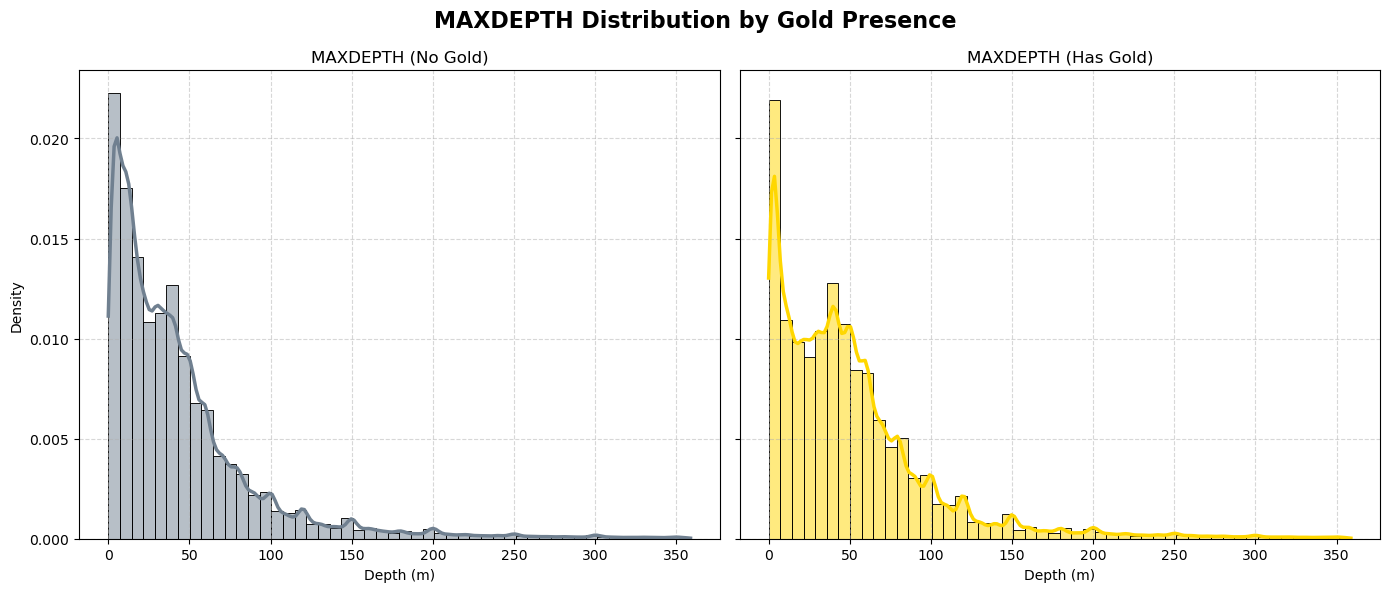

In [47]:
# Filtering out extreme values
max_depth_limit = df['MAXDEPTH'].quantile(0.99)
filtered_df = df[df['MAXDEPTH'] <= max_depth_limit]

# Spliting data based on gold presence
df_gold = filtered_df[filtered_df['HAS_GOLD'] == True]
df_no_gold = filtered_df[filtered_df['HAS_GOLD'] == False]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for "No Gold" with bolder grey tones
sns.histplot(
    df_no_gold['MAXDEPTH'],
    bins=50,
    stat='density',
    color='slategray',  # stronger grey
    kde=True,
    line_kws={'color': 'black', 'linewidth': 2.5},
    ax=axes[0]
)
axes[0].set_title("MAXDEPTH (No Gold)")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("Density")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot for "Has Gold" with stronger yellow
sns.histplot(
    df_gold['MAXDEPTH'],
    bins=50,
    stat='density',
    color='gold',  # strong gold tone
    kde=True,
    line_kws={'color': 'black', 'linewidth': 2.5},
    ax=axes[1]
)
axes[1].set_title("MAXDEPTH (Has Gold)")
axes[1].set_xlabel("Depth (m)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("MAXDEPTH Distribution by Gold Presence", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


📦🔍 **Boxplot Comparison of MAXDEPTH by Gold Presence**

We compare drilling depths (`MAXDEPTH`) between gold-bearing and non-gold holes using side-by-side boxplots. The first plot shows the full range, including outliers. The second plot zooms into depths up to 100 meters to reveal hidden patterns in the majority of the data.


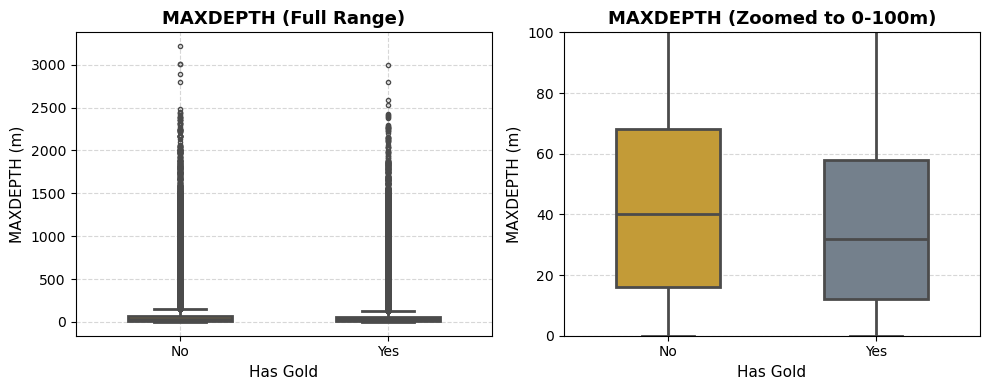

In [49]:
# Finding where HAS_GOLD_STR exists
df['HAS_GOLD_STR'] = df['HAS_GOLD'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# --- Original Boxplot ---
sns.boxplot(
    data=df,
    x='HAS_GOLD_STR',
    y='MAXDEPTH',
    palette={'True': 'goldenrod', 'False': 'slategray'},
    width=0.5,
    fliersize=3,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title("MAXDEPTH (Full Range)", fontsize=13, weight='bold')
axes[0].set_xlabel("Has Gold", fontsize=11)
axes[0].set_ylabel("MAXDEPTH (m)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# --- Zoomed Boxplot ---
sns.boxplot(
    data=df,
    x='HAS_GOLD_STR',
    y='MAXDEPTH',
    palette={'True': 'goldenrod', 'False': 'slategray'},
    width=0.5,
    fliersize=3,
    linewidth=2,
    ax=axes[1]
)
axes[1].set_ylim(0, 100)  # Zoom range (adjustable based on your data)
axes[1].set_title("MAXDEPTH (Zoomed to 0-100m)", fontsize=13, weight='bold')
axes[1].set_xlabel("Has Gold", fontsize=11)
axes[1].set_ylabel("MAXDEPTH (m)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()


🌦️📊 **Strip Plot of MAXDEPTH vs. Gold Presence**

This strip plot visualizes individual drill holes by depth (`MAXDEPTH`) and whether gold was found. Each point represents a hole, colored by gold presence, allowing us to observe clustering and potential depth ranges associated with gold.


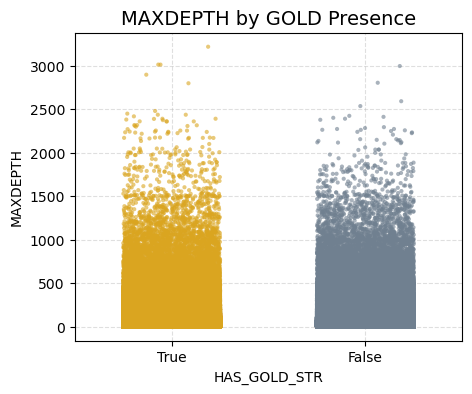

In [51]:
plt.figure(figsize=(5,4))
sns.stripplot(
    data=df,
    x='HAS_GOLD_STR',
    y='MAXDEPTH',
    palette={'True': 'goldenrod', 'False': 'slategray'},
    jitter=0.25,
    size=3,
    alpha=0.6
)
plt.title("MAXDEPTH by GOLD Presence", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


🎻 **Violin Plot of MAXDEPTH vs Gold Presence**

This plot visualizes the distribution and probability density of drill depths (`MAXDEPTH`) for holes with and without gold, offering a richer view than violinoxplot by showing the full shape of the dat
g.


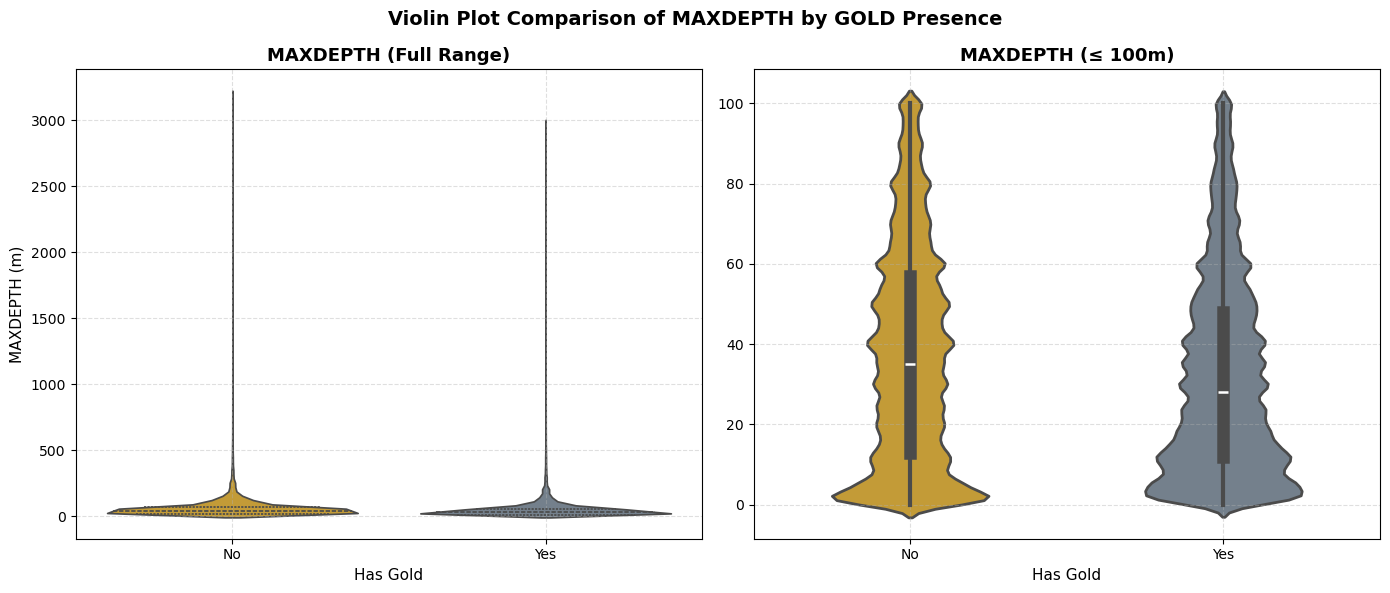

In [53]:
# Make sure the string version of HAS_GOLD is ready
df['HAS_GOLD_STR'] = df['HAS_GOLD'].astype(str)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- Original Violin Plot ---
sns.violinplot(
    data=df,
    x='HAS_GOLD_STR',
    y='MAXDEPTH',
    palette={'True': 'goldenrod', 'False': 'slategray'},
    inner='quartile',
    ax=axes[0]
)
axes[0].set_title("MAXDEPTH (Full Range)", fontsize=13, weight='bold')
axes[0].set_xlabel("Has Gold", fontsize=11)
axes[0].set_ylabel("MAXDEPTH (m)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# --- Zoomed Violin Plot (Capped at 100) ---
sns.violinplot(
    data=df[df['MAXDEPTH'] <= 100],
    x='HAS_GOLD_STR',
    y='MAXDEPTH',
    palette={'True': 'goldenrod', 'False': 'slategray'},
    width=0.5,
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("MAXDEPTH (≤ 100m)", fontsize=13, weight='bold')
axes[1].set_xlabel("Has Gold", fontsize=11)
axes[1].set_ylabel("")  # Avoid repeating y-label
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

plt.suptitle("Violin Plot Comparison of MAXDEPTH by GOLD Presence", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


📊 **HOLETYPE Distribution by GOLD Presence**

This bar plot showcases the percentage distribution of various hole types (`HOLETYPE`) based on whether gold was present or not (`HAS_GOLD`). It allows for a clear comparison of how different hole types contribute to gold presence in the dataset.


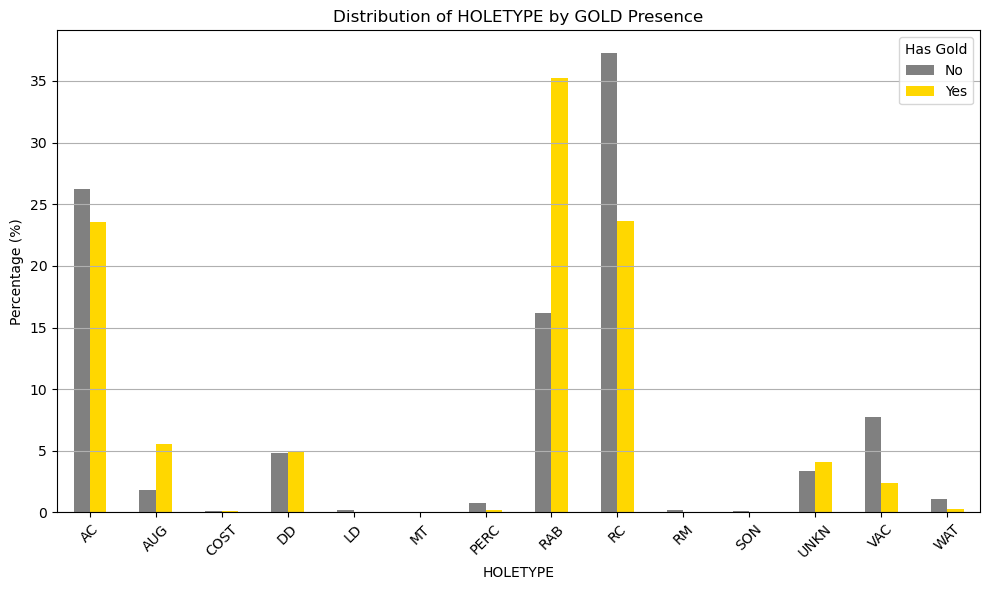

In [55]:
holetype_gold = df.groupby(['HAS_GOLD', 'HOLETYPE']).size().unstack().fillna(0)

# Normalize to percentages for better comparison
holetype_pct = holetype_gold.div(holetype_gold.sum(axis=1), axis=0) * 100

holetype_pct.T.plot(kind='bar', figsize=(10,6), color=['grey', 'gold'])
plt.title("Distribution of HOLETYPE by GOLD Presence")
plt.ylabel("Percentage (%)")
plt.xlabel("HOLETYPE")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title="Has Gold", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


📅 **Drilling Start Year Comparison: GOLD vs. No GOLD**

This dual-histogram plot compares the distribution of drilling start years (`START_YEAR`) for gold and non-gold drilling operations. The left side (in gold) shows drilling start years where gold was present (`HAS_GOLD` is True), while the right side (in grey) illustrates the start years for non-gold operations. This allows us to compare the trends and frequency of drilling activities in different years based on gold presence.


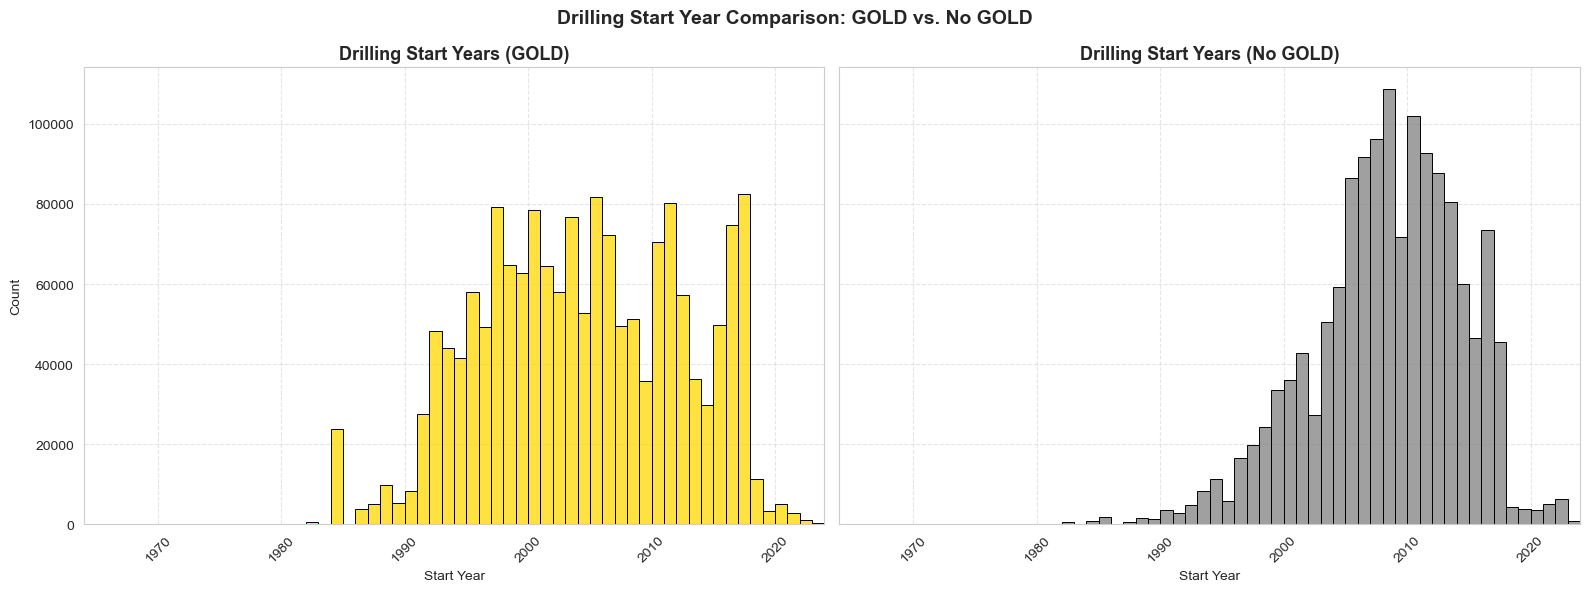

In [57]:
# Set Seaborn style for clarity
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Common bin range for alignment
min_year = df['START_YEAR'].min()
max_year = df['START_YEAR'].max()
bins = range(min_year, max_year + 1)  # 1-year resolution

# --- GOLD (True) ---
sns.histplot(
    data=df[df['HAS_GOLD']],
    x='START_YEAR',
    bins=bins,
    color='gold',
    edgecolor='black',
    linewidth=0.7,
    ax=axes[0]
)
axes[0].set_title("Drilling Start Years (GOLD)", fontsize=13, weight='bold')
axes[0].set_xlabel("Start Year")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xlim(min_year, max_year)
axes[0].tick_params(axis='x', rotation=45)

# --- No GOLD (False) ---
sns.histplot(
    data=df[~df['HAS_GOLD']],
    x='START_YEAR',
    bins=bins,
    color='gray',
    edgecolor='black',
    linewidth=0.7,
    ax=axes[1]
)
axes[1].set_title("Drilling Start Years (No GOLD)", fontsize=13, weight='bold')
axes[1].set_xlabel("Start Year")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xlim(min_year, max_year)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Drilling Start Year Comparison: GOLD vs. No GOLD", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


In [58]:
outliers = df[df['PROJECT_DURATION_DAYS'] > 2000]
print(f"Number of rows with PROJECT_DURATION_DAYS > 2000: {len(outliers)}")
outliers = df[df['PROJECT_DURATION_DAYS'] < 2000]
print(f"Number of rows with PROJECT_DURATION_DAYS < 2000: {len(outliers)}")

Number of rows with PROJECT_DURATION_DAYS > 2000: 381707
Number of rows with PROJECT_DURATION_DAYS < 2000: 2697025


⏳ **Grouped Project Durations: GOLD vs. No GOLD**

This dual-bar plot provides a detailed comparison of project durations (`PROJECT_DURATION_DAYS`) grouped into seven different categories: 
- `0–30d`
- `31–90d`
- `91–180d`
- `181–365d`
- `1–2y`
- `2–3y`
- `3+y`

The plot is split into two sections:
1. **Left Plot (Gold Projects):** This shows the distribution of project durations for drilling projects where gold is present (`HAS_GOLD` = True). The bars are colored in **gold** and include percentage annotations to indicate the proportion of projects falling within each duration category. 
   
2. **Right Plot (Non-Gold Projects):** This presents the same project durations, but for drilling projects without gold (`HAS_GOLD` = False). These bars are colored in **gray** and also feature percentage annotations to showcase the distribution for non-gold projects.

The purpose of this visualization is to help us understand how the duration of drilling projects varies between those with gold and those without. Are gold-related projects typically shorter or longer? Are there any patterns in project durations based on the presence of gold? The percentage annotations provide clarity on the share of total projects within each group, aiding in quick comparisons between the two categories.

Additionally, both plots utilize a clean, structured approach with well-defined duration groups, making it easy to analyze trends in drilling project timelines relative to gold presence.


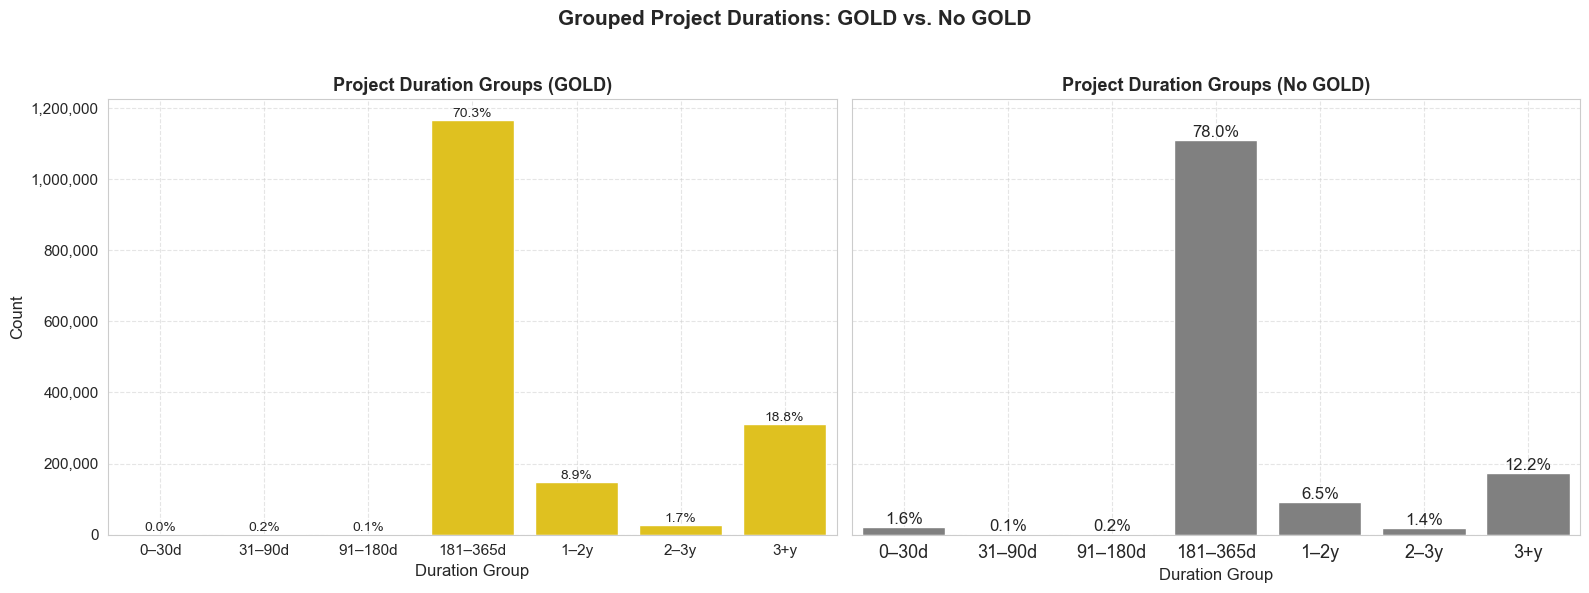

In [60]:
# Define bins and labels
bins = [0, 30, 90, 180, 365, 730, 1095, df['PROJECT_DURATION_DAYS'].max()]
labels = ['0–30d', '31–90d', '91–180d', '181–365d', '1–2y', '2–3y', '3+y']

# Create a new column for grouped durations
df['DURATION_GROUP'] = pd.cut(df['PROJECT_DURATION_DAYS'], bins=bins, labels=labels, right=True)

# Calculate total counts for gold and non-gold
gold_total = df['HAS_GOLD'].sum()
non_gold_total = (~df['HAS_GOLD']).sum()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- GOLD PLOT ---
gold_data = df[df['HAS_GOLD']]['DURATION_GROUP'].value_counts().reindex(labels, fill_value=0)
sns.countplot(
    data=df[df['HAS_GOLD']],
    x='DURATION_GROUP',
    order=labels,
    color='gold',
    ax=axes[0]
)
axes[0].set_title("Project Duration Groups (GOLD)", fontsize=13, weight='bold')
axes[0].set_xlabel("Duration Group", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Add percentage annotations for GOLD
for i, p in enumerate(axes[0].patches):
    count = gold_data[i]
    pct = (count / gold_total) * 100 if gold_total > 0 else 0
    axes[0].annotate(f'{pct:.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# --- NO GOLD PLOT ---
no_gold_data = df[~df['HAS_GOLD']]['DURATION_GROUP'].value_counts().reindex(labels, fill_value=0)
sns.countplot(
    data=df[~df['HAS_GOLD']],
    x='DURATION_GROUP',
    order=labels,
    color='gray',
    ax=axes[1]
)
axes[1].set_title("Project Duration Groups (No GOLD)", fontsize=13, weight='bold')
axes[1].set_xlabel("Duration Group", fontsize=12)
axes[1].set_ylabel("", fontsize=12)
axes[1].tick_params(axis='x', labelsize=13)
axes[1].tick_params(axis='y', labelsize=13)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add percentage annotations for NO GOLD
for i, p in enumerate(axes[1].patches):
    count = no_gold_data[i]
    pct = (count / non_gold_total) * 100 if non_gold_total > 0 else 0
    axes[1].annotate(f'{pct:.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Format y-axis numbers
for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Super title and layout
plt.suptitle("Grouped Project Durations: GOLD vs. No GOLD", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 🔧 Final Preprocessing Summary (Before Modeling)

Before moving into modeling, the dataset has been finalized with the following adjustments:

- **Categorical Conversion:**
  - Converted `OPERATOR` and `PROJECT` columns to the `category` dtype to reduce memory usage and prepare for modeling.

- **Target Variable Preparation:**
  - The target column `HAS_GOLD` has been encoded as `int8` (0 = No Gold, 1 = Gold) for binary classification tasks.

- **Feature Removal:**
  - Dropped non-essential or redundant columns:
    - Identification fields: `HOLEID`, `TARGET_COMMODITY`, `HOLETYPE`
    - Date-related helper columns: `PERIOD_FROM_CLEAN`, `PERIOD_TO_CLEAN`, `START_MONTH`, `END_MONTH`, `END_YEAR`
    - Visualization-only columns: `HAS_GOLD_STR`, `DURATION_GROUP`

- **Missing Data Check:**
  - Confirmed there are **no missing values** in the dataset using `eady for modeling.


In [62]:
cols_to_convert = [ 'OPERATOR', 'PROJECT']
for col in cols_to_convert:
    df[col] = df[col].astype('category')

In [63]:
df['HAS_GOLD'] = df['HAS_GOLD'].astype('int8')


In [64]:
df.drop(columns=['TARGET_COMMODITY','HOLETYPE','HOLEID',
    'PERIOD_FROM_CLEAN', 'PERIOD_TO_CLEAN',
    'START_MONTH', 'END_MONTH','HAS_GOLD_STR', 'DURATION_GROUP',
    'END_YEAR'  # optional, if keeping START_YEAR
], inplace=True)

In [65]:
df.isna().sum()

OBJECTID                 0
COLLARID                 0
LATITUDE                 0
LONGITUDE                0
MAXDEPTH                 0
OPERATOR                 0
PROJECT                  0
ANUMBER                  0
PERIOD_FROM              0
PERIOD_TO                0
HAS_GOLD                 0
START_YEAR               0
PROJECT_DURATION_DAYS    0
HOLETYPE_CAT             0
dtype: int64

## 🚀 Modeling Phase Begins

With our dataset now fully cleaned and encoded, we move into the **modeling phase**, focusing exclusively on **tree-based classification models**. This decision follows initial performance evaluations, where tree models consistently outperformed linear models and offered a more balanced and robust output.

In this stage, we:
- Define the **feature matrix** (`X`) and the **target variable** (`HAS_GOLD`).
- Split the data into **training** and **testing** subsets for evaluation.
- Preserve clean copies of our data (`X_train_encoded`, `X_test_encoded`) for transformation and model input.
- Focus entirely on **tree-based classifiers** (e.g., Random Forest, Gradient Boosting, XGBoost, LightGBM, etc.).
- Evaluate model performance using metrics like **accuracy**, **precision**, **recall**, and **F1-score**.
- Leverage **feature importance analysis** to gain insights into which variables most influence gold presence.

This focused approach simplifies the modeling pipeline and ensures alignment with the best-performing methods identified earlier.
tor (`y`).


In [67]:
# Separate features and target
X = df.drop(['HAS_GOLD'], axis=1)
y = df['HAS_GOLD']


In [68]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
# Make copies before transformation
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()


### 🔢 Encoding Categorical Features

To prepare categorical variables for machine learning models, we apply **Ordinal Encoding**. This process transforms category labels into integer values so that models can interpret them numerically.

We use `OrdinalEncoder` from `sklearn.preprocessing`, with specific handling for unknown categories in the test set:

- `handle_unknown='use_encoded_value'` ensures unseen categories during prediction are handled gracefully.
- `unknown_value=-1` assigns a default code to unknown categories.

This encoding is applied only to columns with `category` data types in both training and test datasets (`X_train_encoded` and `X_test_encoded`).


In [71]:
# Applying OrdinalEncoder with handling unknown categories
cat_cols = X.select_dtypes(include='category').columns

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded[cat_cols] = ordinal_encoder.fit_transform(X_train_encoded[cat_cols])
X_test_encoded[cat_cols] = ordinal_encoder.transform(X_test_encoded[cat_cols])



### 🔍 Model Evaluation Setup

Before proceeding to train and compare classification models, we define a standardized evaluation function called `evaluate_classifier`. This function takes the model name, actual target values (`y_true`), and predicted values (`y_pred`) to compute and display key classification metrics:

- **Accuracy** – Overall correctness of the model.
- **Precision** – How many predicted positives were actually correct (weighted average across classes).
- **Recall** – How many actual positives were captured by the model (weighted).
- **F1 Score** – Harmonic mean of precision and recall.
- **Classification Report** – A detailed breakdown of all metrics per class.

This evaluation will be applied to each model after prediction to ensure a consistent and interpretable comparison.


In [73]:
def evaluate_classifier(model_name, y_true, y_pred):
    print(f"\nModel: {model_name}")
    print("-" * 40)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average='weighted'), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average='weighted'), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred, average='weighted'), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


#### 🌳 Decision Tree Classifier

In [75]:
# Initialize the model_results dictionary *once* outside all model blocks
model_results = {}  #← (if not already declared earlier)

# Initialize and train the model
dtree = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=None,     # Full depth
    min_samples_split=2,
    random_state=42
)
dtree.fit(X_train_encoded, y_train)

# Make predictions
dtree_preds = dtree.predict(X_test_encoded)

# Evaluate
evaluate_classifier("Decision Tree Classifier", y_test, dtree_preds)

# Store model and its evaluation
model_results["Decision Tree Classifier"] = {
    "model": dtree,
    "accuracy": accuracy_score(y_test, dtree_preds),
    "precision": precision_score(y_test, dtree_preds, average='weighted'),
    "recall": recall_score(y_test, dtree_preds, average='weighted'),
    "f1": f1_score(y_test, dtree_preds, average='weighted'),
    "feature_importance": dtree.feature_importances_
}



Model: Decision Tree Classifier
----------------------------------------
Accuracy : 0.9997
Precision: 0.9997
Recall   : 0.9997
F1 Score : 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284028
           1       1.00      1.00      1.00    331719

    accuracy                           1.00    615747
   macro avg       1.00      1.00      1.00    615747
weighted avg       1.00      1.00      1.00    615747



#### 🌲 Limited Decision Tree 

In [77]:
# Initialize Limited Decision Tree
dtree_limited = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

# Fit the model
dtree_limited.fit(X_train_encoded, y_train)

# Make predictions
dtree_limited_preds = dtree_limited.predict(X_test_encoded)

# Evaluate the model
evaluate_classifier("Limited Decision Tree", y_test, dtree_limited_preds)

# Store model and its evaluation
model_results["Limited Decision Tree"] = {
    "model": dtree_limited,
    "accuracy": accuracy_score(y_test, dtree_limited_preds),
    "precision": precision_score(y_test, dtree_limited_preds, average='weighted'),
    "recall": recall_score(y_test, dtree_limited_preds, average='weighted'),
    "f1": f1_score(y_test, dtree_limited_preds, average='weighted'),
    "feature_importance": dtree_limited.feature_importances_
}



Model: Limited Decision Tree
----------------------------------------
Accuracy : 0.8671
Precision: 0.8725
Recall   : 0.8671
F1 Score : 0.8658

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84    284028
           1       0.84      0.94      0.88    331719

    accuracy                           0.87    615747
   macro avg       0.88      0.86      0.86    615747
weighted avg       0.87      0.87      0.87    615747



#### 🌳 Random Forest Classifier

In [79]:
# Train the model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_encoded, y_train)
rf_preds = rf.predict(X_test_encoded)

# Evaluate
evaluate_classifier("Random Forest", y_test, rf_preds)

# Initialize the model_results dictionary *once* outside all model blocks
# model_results = {}  ← (if not already declared earlier)

# Store model and its evaluation
model_results["Random Forest"] = {
    "model": rf,
    "accuracy": accuracy_score(y_test, rf_preds),
    "precision": precision_score(y_test, rf_preds, average='weighted'),
    "recall": recall_score(y_test, rf_preds, average='weighted'),
    "f1": f1_score(y_test, rf_preds, average='weighted'),
    "feature_importance": rf.feature_importances_
}



Model: Random Forest
----------------------------------------
Accuracy : 0.9145
Precision: 0.9179
Recall   : 0.9145
F1 Score : 0.914

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90    284028
           1       0.89      0.97      0.92    331719

    accuracy                           0.91    615747
   macro avg       0.92      0.91      0.91    615747
weighted avg       0.92      0.91      0.91    615747



#### 🍃 Gradient Boosting

In [81]:
# Initialize Gradient Boosting Classifier
gbc = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

# Fit the model
gbc.fit(X_train_encoded, y_train)

# Make predictions
gbc_preds = gbc.predict(X_test_encoded)

# Evaluate the model
evaluate_classifier("Gradient Boosting", y_test, gbc_preds)

# Store model and its evaluation
model_results["Gradient Boosting"] = {
    "model": gbc,
    "accuracy": accuracy_score(y_test, gbc_preds),
    "precision": precision_score(y_test, gbc_preds, average='weighted'),
    "recall": recall_score(y_test, gbc_preds, average='weighted'),
    "f1": f1_score(y_test, gbc_preds, average='weighted'),
    "feature_importance": gbc.feature_importances_
}



Model: Gradient Boosting
----------------------------------------
Accuracy : 0.8589
Precision: 0.8613
Recall   : 0.8589
F1 Score : 0.8581

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84    284028
           1       0.84      0.91      0.87    331719

    accuracy                           0.86    615747
   macro avg       0.86      0.85      0.86    615747
weighted avg       0.86      0.86      0.86    615747



#### ⛳️ XG Boost

In [83]:
# Initialize XGBoost Classifier
xgboost_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # to suppress warning
)

# Fit the model
xgboost_model.fit(X_train_encoded, y_train)

# Make predictions
xgboost_preds = xgboost_model.predict(X_test_encoded)

# Evaluate the model
evaluate_classifier("XGBoost", y_test, xgboost_preds)

# Store model and its evaluation
model_results["XGBoost"] = {
    "model": xgboost_model,
    "accuracy": accuracy_score(y_test, xgboost_preds),
    "precision": precision_score(y_test, xgboost_preds, average='weighted'),
    "recall": recall_score(y_test, xgboost_preds, average='weighted'),
    "f1": f1_score(y_test, xgboost_preds, average='weighted'),
    "feature_importance": xgboost_model.feature_importances_
}



Model: XGBoost
----------------------------------------
Accuracy : 0.8486
Precision: 0.8524
Recall   : 0.8486
F1 Score : 0.8473

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.82    284028
           1       0.82      0.92      0.87    331719

    accuracy                           0.85    615747
   macro avg       0.85      0.84      0.85    615747
weighted avg       0.85      0.85      0.85    615747



#### 🧩 Cat Boost

In [85]:
# Initialize CatBoost Classifier
catboost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_seed=42,
    verbose=0
)

# Fit the model
catboost_model.fit(X_train_encoded, y_train)

# Make predictions
catboost_preds = catboost_model.predict(X_test_encoded)

# Evaluate the model
evaluate_classifier("CatBoost", y_test, catboost_preds)

# Store model and its evaluation
model_results["CatBoost"] = {
    "model": catboost_model,
    "accuracy": accuracy_score(y_test, catboost_preds),
    "precision": precision_score(y_test, catboost_preds, average='weighted'),
    "recall": recall_score(y_test, catboost_preds, average='weighted'),
    "f1": f1_score(y_test, catboost_preds, average='weighted'),
    "feature_importance": catboost_model.feature_importances_
}



Model: CatBoost
----------------------------------------
Accuracy : 0.8272
Precision: 0.8308
Recall   : 0.8272
F1 Score : 0.8256

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80    284028
           1       0.80      0.90      0.85    331719

    accuracy                           0.83    615747
   macro avg       0.83      0.82      0.82    615747
weighted avg       0.83      0.83      0.83    615747



#### 🛤 LightGBM

In [87]:
# Initialize LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit the model
lgbm_model.fit(X_train_encoded, y_train)

# Make predictions
lgbm_preds = lgbm_model.predict(X_test_encoded)

# Evaluate the model
evaluate_classifier("LightGBM", y_test, lgbm_preds)

# Store model and its evaluation
model_results["LightGBM"] = {
    "model": lgbm_model,
    "accuracy": accuracy_score(y_test, lgbm_preds),
    "precision": precision_score(y_test, lgbm_preds, average='weighted'),
    "recall": recall_score(y_test, lgbm_preds, average='weighted'),
    "f1": f1_score(y_test, lgbm_preds, average='weighted'),
    "feature_importance": lgbm_model.feature_importances_
}


[LightGBM] [Info] Number of positive: 1325921, number of negative: 1137064
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2851
[LightGBM] [Info] Number of data points in the train set: 2462985, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.538339 -> initscore=0.153658
[LightGBM] [Info] Start training from score 0.153658
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

### 🗺️ Summary

In [89]:
# Create a summary DataFrame from the model_results dictionary
summary_df = pd.DataFrame([
    {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1']
    }
    for model_name, metrics in model_results.items()
])

# Sort by F1 Score (or any other metric if preferred)
summary_df = summary_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# Display the summary
print(summary_df)


                      Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree Classifier  0.999682   0.999682  0.999682  0.999682
1             Random Forest  0.914496   0.917888  0.914496  0.913962
2     Limited Decision Tree  0.867145   0.872546  0.867145  0.865841
3         Gradient Boosting  0.858926   0.861299  0.858926  0.858054
4                   XGBoost  0.848571   0.852421  0.848571  0.847280
5                  LightGBM  0.847398   0.852190  0.847398  0.845905
6                  CatBoost  0.827190   0.830843  0.827190  0.825632


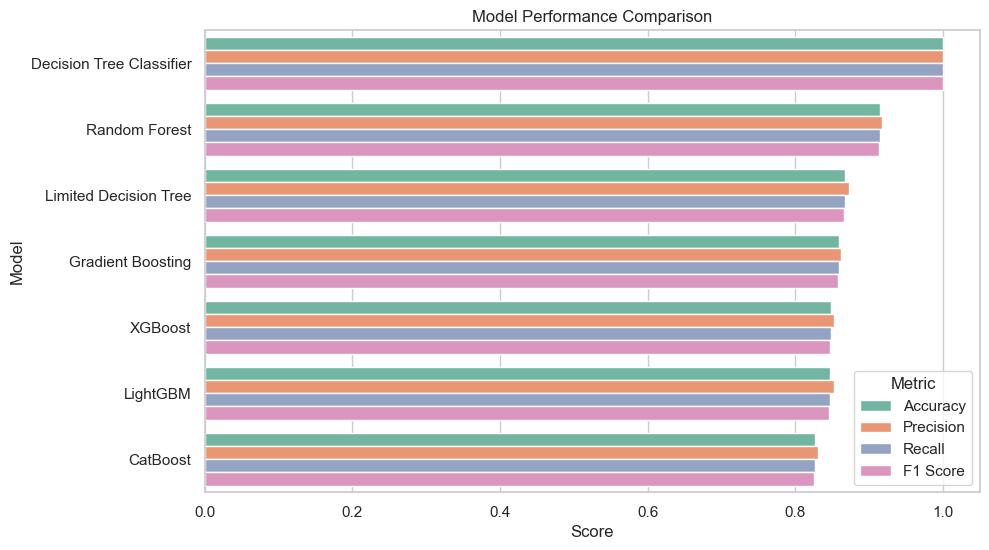

In [90]:
# Set the figure size and style for plots
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Reshape the summary data for plotting
summary_melted = summary_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Create a bar plot
sns.barplot(x='Score', y='Model', hue='Metric', data=summary_melted, palette='Set2')

# Adding labels and title
plt.title('Model Performance Comparison')
plt.xlabel('Score')
plt.ylabel('Model')
plt.legend(title='Metric')
plt.show()


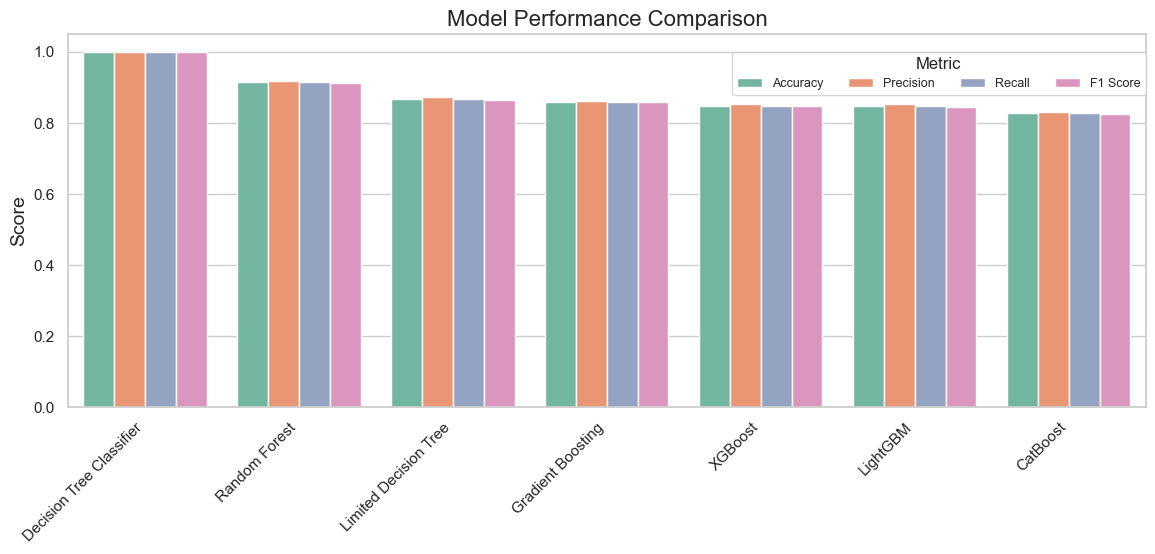

In [91]:
# Set the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Reshape the summary data
summary_melted = summary_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Create the bar plot
sns.barplot(x='Model', y='Score', hue='Metric', data=summary_melted, palette='Set2', ci=None)

# Title and Y-axis only
plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=14)
plt.xlabel('')  # remove x-axis label
plt.xticks(rotation=45, ha='right')

# Legend inside the plot at the top, horizontally
plt.legend(
    title='Metric',
    loc='upper center',
    bbox_to_anchor=(0.808, 0.97),
    ncol=4,
    frameon=True,
    fontsize=9,
    title_fontsize=12
)

# Adjust layout to avoid clipping
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


### 🏹Feature Importance

In [93]:
# Get feature importances from each trained model
feature_importances = {
    'Random Forest': rf.feature_importances_,
    'Gradient Boosting': gbc.feature_importances_,
    'XGBoost': xgboost_model.feature_importances_,
    'CatBoost': catboost_model.get_feature_importance(),
    'LightGBM': lgbm_model.feature_importances_,
    'Decision Tree': dtree.feature_importances_,
    'Limited Decision Tree': dtree_limited.feature_importances_
}


In [94]:
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded[cat_cols] = ordinal_encoder.fit_transform(X_train_encoded[cat_cols])
X_test_encoded[cat_cols] = ordinal_encoder.transform(X_test_encoded[cat_cols])


In [95]:
# Get feature names (same as original since using OrdinalEncoder)
feature_names = X_train_encoded.columns

# Normalize function
def normalize_importances(importances):
    total = builtins.sum(importances)
    return [i / total for i in importances]

# Normalize if needed
normalized_feature_importances = {}
for model_name, importances in feature_importances.items():
    if abs(builtins.sum(importances) - 1.0) > 0.01:
        importances = normalize_importances(importances)
    normalized_feature_importances[model_name] = importances

# Display results
print("="*60)
print("FEATURE IMPORTANCE COMPARISON ACROSS MODELS")
print("="*60)

for model_name, importances in normalized_feature_importances.items():
    print(f"\nModel: {model_name}")
    print("-" * 60)
    for feature, importance in zip(feature_names, importances):
        print(f"{feature:<30} {importance:.4f}")


FEATURE IMPORTANCE COMPARISON ACROSS MODELS

Model: Random Forest
------------------------------------------------------------
OBJECTID                       0.0595
COLLARID                       0.0414
LATITUDE                       0.2176
LONGITUDE                      0.2126
MAXDEPTH                       0.0094
OPERATOR                       0.1013
PROJECT                        0.0527
ANUMBER                        0.0762
PERIOD_FROM                    0.0896
PERIOD_TO                      0.0391
START_YEAR                     0.0566
PROJECT_DURATION_DAYS          0.0203
HOLETYPE_CAT                   0.0238

Model: Gradient Boosting
------------------------------------------------------------
OBJECTID                       0.0140
COLLARID                       0.0224
LATITUDE                       0.2876
LONGITUDE                      0.2699
MAXDEPTH                       0.0051
OPERATOR                       0.1298
PROJECT                        0.0361
ANUMBER                   

In [96]:
# Create a DataFrame from the normalized_feature_importances dictionary
feature_importance_df = pd.DataFrame(normalized_feature_importances, index=feature_names)

# Optional: Sort features by average importance across models
feature_importance_df['Mean_Importance'] = feature_importance_df.mean(axis=1)
feature_importance_df = feature_importance_df.sort_values(by='Mean_Importance', ascending=False)
feature_importance_df.drop(columns='Mean_Importance', inplace=True)

# Display the DataFrame
print(feature_importance_df)


                       Random Forest  Gradient Boosting   XGBoost  CatBoost  \
LATITUDE                    0.217582           0.287552  0.141855  0.287398   
LONGITUDE                   0.212554           0.269924  0.125888  0.274091   
PERIOD_FROM                 0.089648           0.158464  0.176911  0.125845   
OPERATOR                    0.101325           0.129780  0.088816  0.127487   
PROJECT                     0.052664           0.036131  0.055562  0.037571   
ANUMBER                     0.076166           0.038864  0.071226  0.033588   
OBJECTID                    0.059533           0.014045  0.109325  0.021381   
COLLARID                    0.041379           0.022435  0.029544  0.022341   
PERIOD_TO                   0.039100           0.016054  0.074892  0.025815   
HOLETYPE_CAT                0.023762           0.011149  0.057964  0.018060   
PROJECT_DURATION_DAYS       0.020332           0.007228  0.043413  0.002297   
START_YEAR                  0.056560           0.003

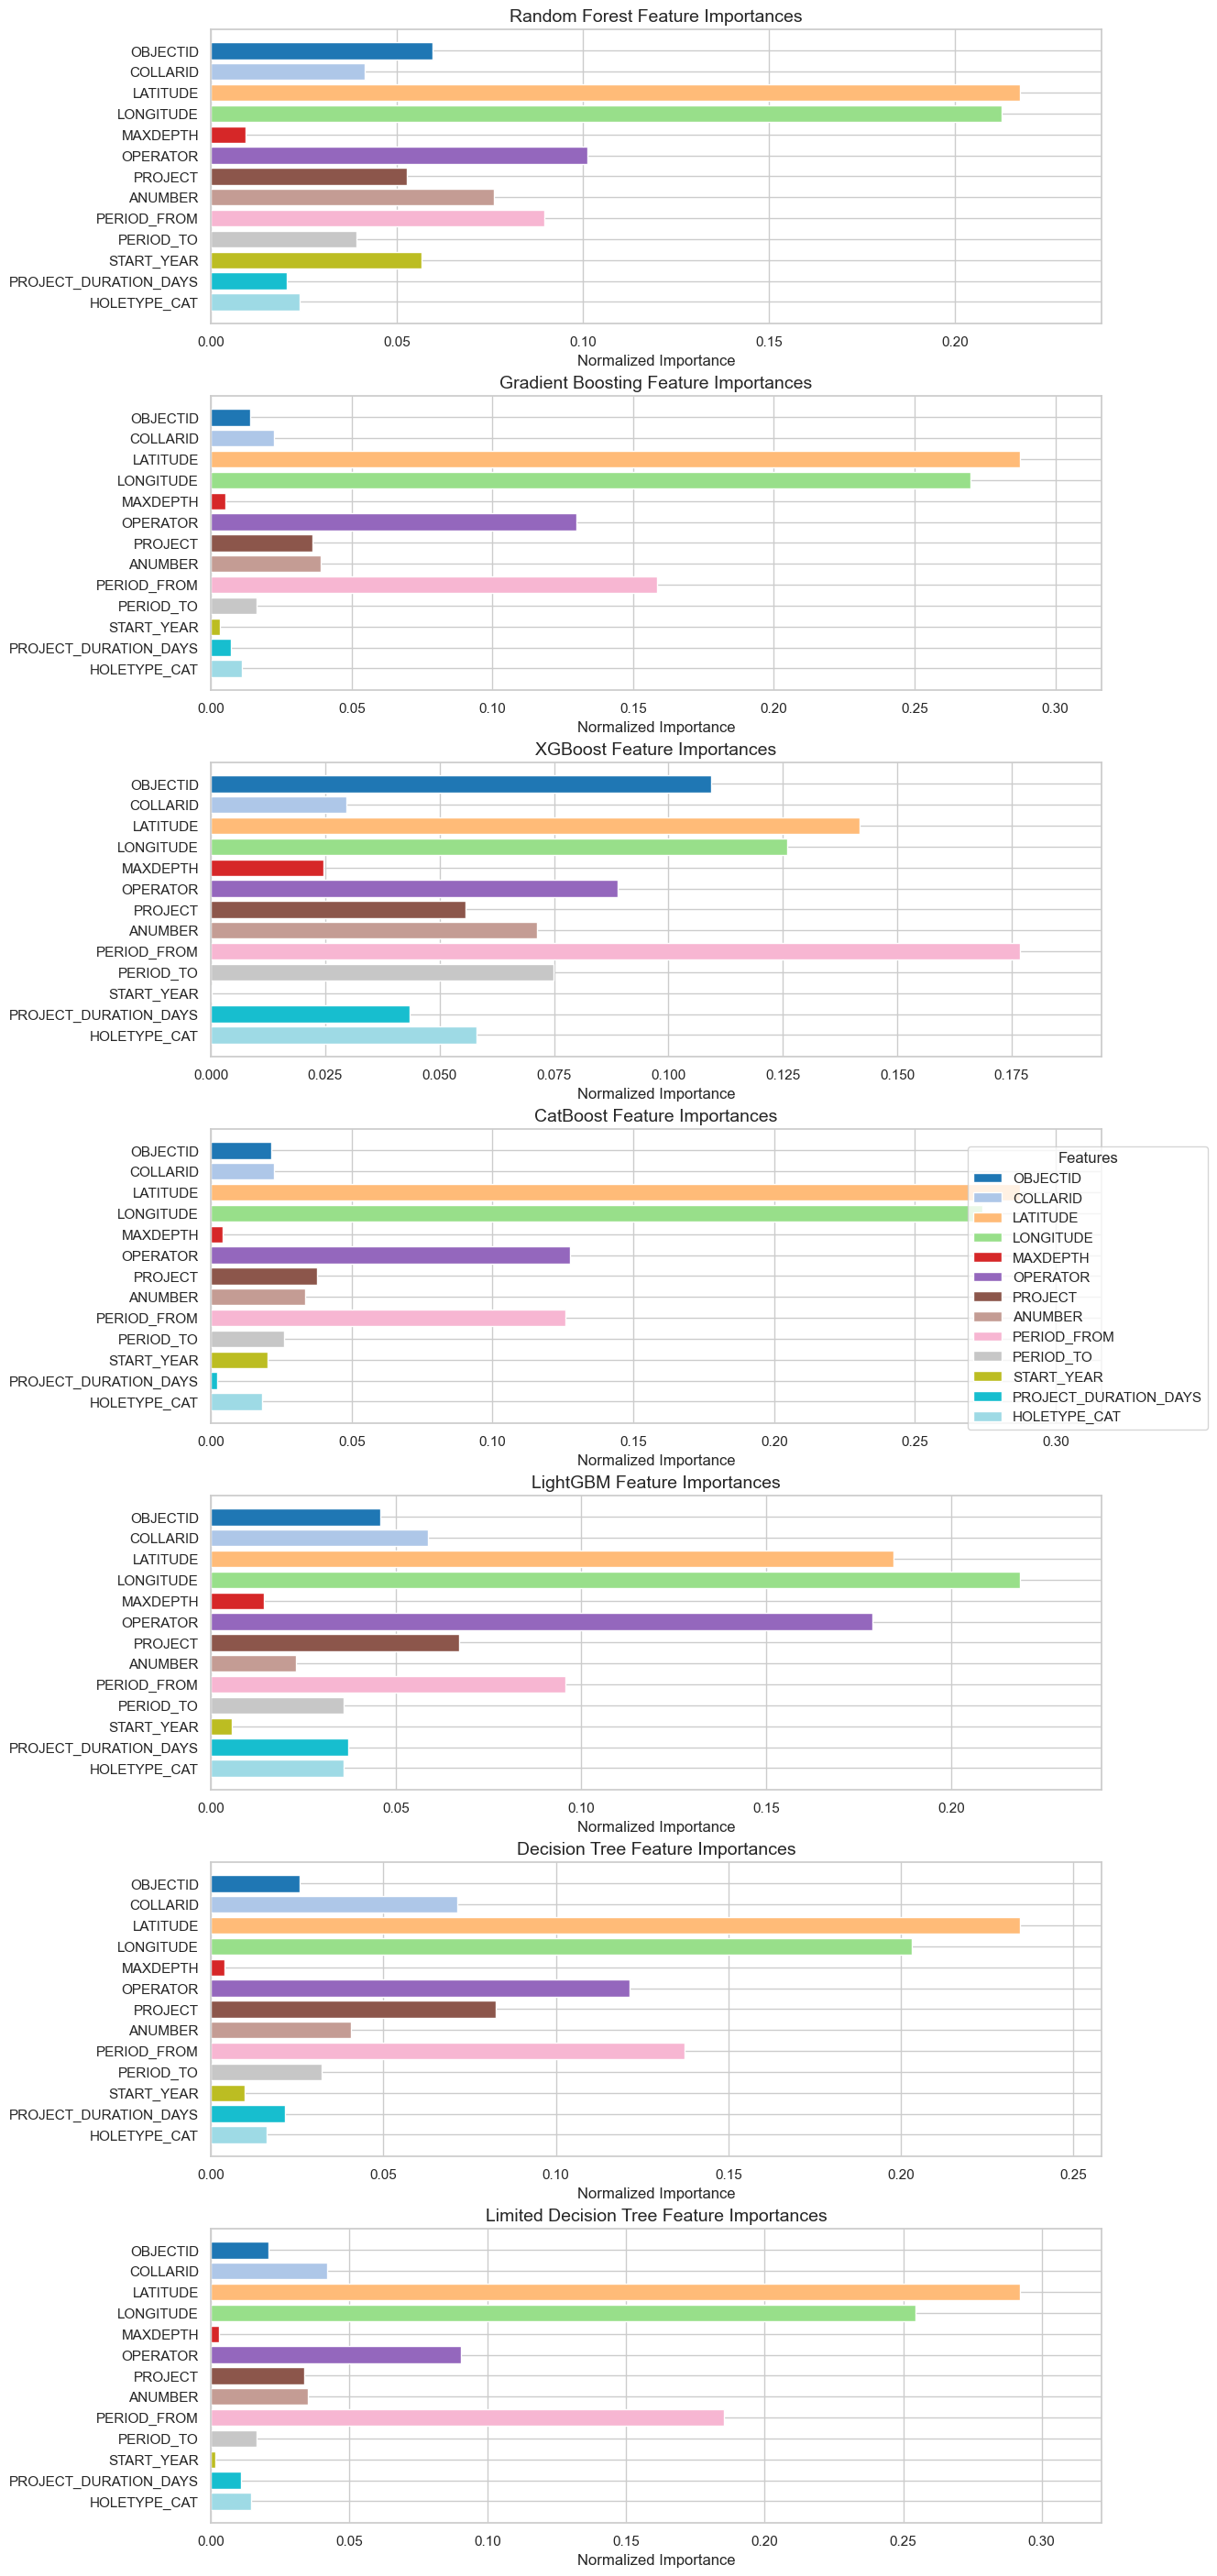

In [97]:
# Generate a consistent color map based on feature names
num_features = len(feature_names)
colors = cm.get_cmap('tab20', num_features)(range(num_features))  # 20 distinct colors, loops if > 20

# Map features to specific colors
feature_color_map = dict(zip(feature_names, colors))

# Plotting
num_models = len(normalized_feature_importances)
fig, axes = plt.subplots(nrows=num_models, ncols=1, figsize=(12, 4 * num_models), constrained_layout=True)

if num_models == 1:
    axes = [axes]

for ax, (model_name, importances) in zip(axes, normalized_feature_importances.items()):
    feature_colors = [feature_color_map[f] for f in feature_names]
    ax.barh(feature_names, importances, color=feature_colors)
    ax.set_title(f'{model_name} Feature Importances', fontsize=14)
    ax.set_xlim(0, max(importances) * 1.1)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized Importance')

# Optional: Show legend (one time only, outside the plots)
# This adds one patch per feature in the legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=feature_color_map[f], label=f) for f in feature_names]
fig.legend(handles=legend_elements, loc='center right', title='Features', bbox_to_anchor=(1.1, 0.5))

plt.show()
